# A Study on Arrhythmia via ECG Signal Classification Using the Convolutional Neural Network



This is an implementation to the paper **"A Study on Arrhythmia via ECG Signal Classification Using the Convolutional Neural Network"**. 




# Imports


In [1]:
import numpy as np
import pandas as pd
import os
import csv
import matplotlib.pyplot as plt
import pywt
from scipy import stats

from sklearn.utils import resample
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# matplotlib Settings

In [2]:
# -----------------------------
# 0) Utils (same as your notebook style)
# -----------------------------
def denoise(data):
    w = pywt.Wavelet('sym4')
    maxlev = pywt.dwt_max_level(len(data), w.dec_len)
    threshold = 0.04

    coeffs = pywt.wavedec(data, 'sym4', level=maxlev)
    for i in range(1, len(coeffs)):
        coeffs[i] = pywt.threshold(coeffs[i], threshold * max(coeffs[i]))
    datarec = pywt.waverec(coeffs, 'sym4')
    return datarec

# Methods Definitions

In [3]:
# ============================================================
# 1) DATASET LOADER (matches your notebook logic)
# Folder contains:
#   - many .csv record files (signal in column index 1)
#   - many annotation text files where filename contains "annotation"
# ============================================================
def load_mitbih_from_csv_annotation_folder(
    path,
    window_size=1000,
    classes=('N', 'L', 'R', 'A', 'V'),
    plot_example=True
):
    """
    Replicates your notebook loading logic:
    - reads all .csv (signals) and all annotation *.txt (contains 'annotation' in name)
    - extracts beats around annotated positions using +/- window_size
    - z-score normalization on signals
    - returns X_train_df DataFrame where last column is label index (0..4)
    """
    classes = list(classes)
    n_classes = len(classes)
    count_classes = [0] * n_classes

    # Read files
    filenames = next(os.walk(path))[2]
    filenames.sort()

    records, annotations = [], []
    for f in filenames:
        base, ext = os.path.splitext(f)
        full = os.path.join(path, f)

        if ext.lower() == ".csv":
            records.append(full)
        elif ext.lower() == ".txt" and "annotation" in base.lower():
            annotations.append(full)

    if len(records) == 0 or len(annotations) == 0:
        raise FileNotFoundError(
            "No records/annotations found. Expected .csv files and annotation .txt files containing 'annotation' in name."
        )

    # You assumed same ordering in your notebook; to be safer we keep sorted.
    # If they mismatch, you should ensure matching pairs by filename convention.
    records.sort()
    annotations.sort()

    X, y = [], []

    for r in range(min(len(records), len(annotations))):
        signals = []

        # --- Read CSV signal (your notebook used int(row[1])) ---
        with open(records[r], 'rt') as csvfile:
            spamreader = csv.reader(csvfile, delimiter=',', quotechar='|')
            row_index = -1
            for row in spamreader:
                if row_index >= 0:
                    # In your notebook: int(row[1])
                    signals.insert(row_index, int(row[1]))
                row_index += 1

        # Optional example plots (same style)
        if plot_example and r == 1:
            plt.title(records[1] + " Wave")
            plt.plot(signals[0:700])
            plt.show()

        # NOTE: your notebook had denoise() defined but didn't apply it here.
        # We keep your behavior: z-score normalization only.
        signals = stats.zscore(signals)

        if plot_example and r == 1:
            plt.title(records[1] + " wave after z-score normalization ")
            plt.plot(signals[0:700])
            plt.show()

        # --- Read annotations ---
        example_beat_printed = False
        with open(annotations[r], 'r') as fileID:
            data = fileID.readlines()

            for d in range(1, len(data)):  # 0 index is chart head
                splitted = data[d].split(' ')
                splitted = filter(None, splitted)

                # Your notebook logic:
                # next(splitted) -> time
                # pos = int(next(splitted))
                # arrhythmia_type = next(splitted)
                try:
                    next(splitted)
                    pos = int(next(splitted))
                    arrhythmia_type = next(splitted)
                except StopIteration:
                    continue

                if arrhythmia_type in classes:
                    arrhythmia_index = classes.index(arrhythmia_type)
                    count_classes[arrhythmia_index] += 1

                    if window_size <= pos < (len(signals) - window_size):
                        beat = signals[pos - window_size: pos + window_size]

                        if plot_example and r == 1 and not example_beat_printed:
                            plt.title("A Beat from " + records[1] + " Wave")
                            plt.plot(beat)
                            plt.show()
                            example_beat_printed = True

                        X.append(beat)
                        y.append(arrhythmia_index)

    print("Loaded beats:", np.shape(X), "labels:", np.shape(y))
    print("Per-class counts:", count_classes)

    # Append label to end of each beat (same as your notebook)
    X = [np.append(X[i], y[i]) for i in range(len(X))]

    X_train_df = pd.DataFrame(X)
    return X_train_df, classes

* **N (Normal):** The "N" represents a normal heartbeat or cardiac complex. It indicates that the electrical activity of the heart is within the normal range, and there are no abnormalities or irregularities in the heart rhythm.
* **L (Left bundle branch block):** An "L" complex indicates the presence of a left bundle branch block. This is an abnormality in the electrical conduction system of the heart, where the electrical signals do not travel normally through the left bundle branch. It can affect the timing and coordination of ventricular contractions.
* **R (Right bundle branch block):** An "R" complex indicates a right bundle branch block. Similar to left bundle branch block, this signifies an abnormality in the electrical conduction system involving the right bundle branch.
* **A (Atrial premature beat):** An "A" complex represents an atrial premature beat, which is an early contraction originating in the atria (upper chambers of the heart) before the next expected normal heartbeat.
* **V (Ventricular premature beat):** A "V" complex represents a ventricular premature beat, which is an early contraction originating in the ventricles (lower chambers of the heart) before the next expected normal heartbeat.


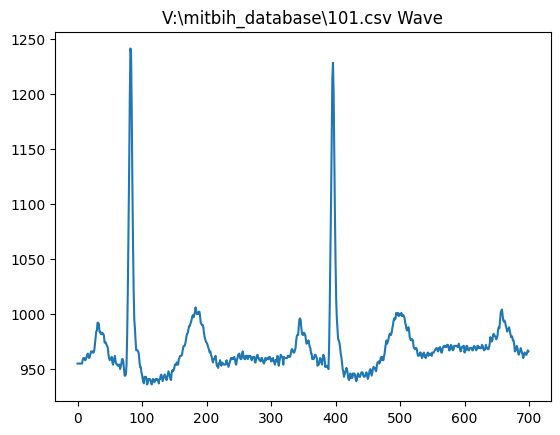

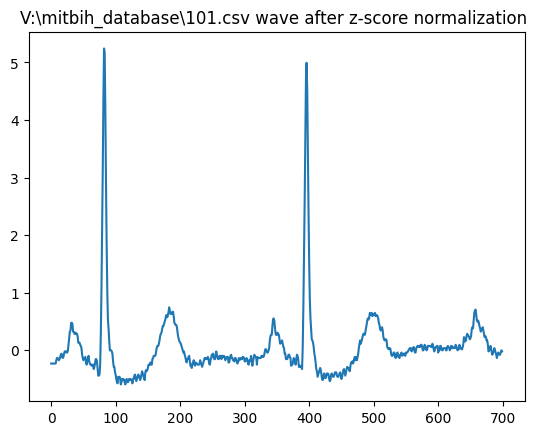

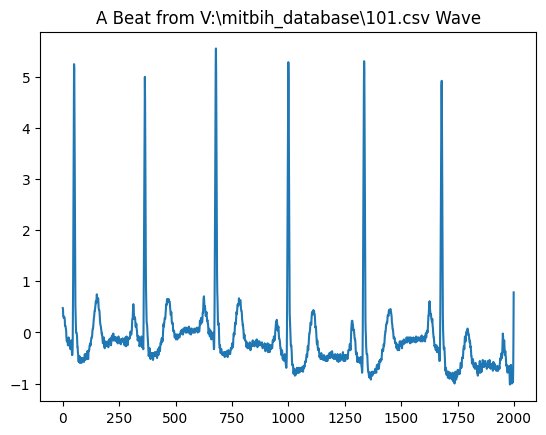

Loaded beats: (99754, 2000) labels: (99754,)
Per-class counts: [75052, 8075, 7259, 2546, 7130]
2000
0.0    74815
1.0     8053
2.0     7235
4.0     7114
3.0     2537
Name: count, dtype: int64


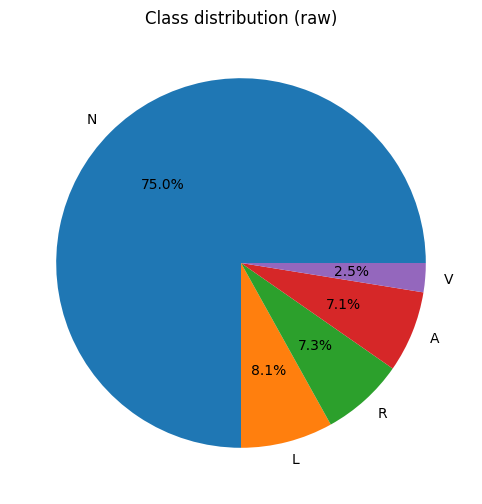

In [4]:
# ============================================================
# 2) LOAD DATA (USE THIS)
# ============================================================
path = r"V:\mitbih_database"   # <- same as your notebook
window_size = 1000

X_train_df, classes = load_mitbih_from_csv_annotation_folder(
    path=path,
    window_size=window_size,
    classes=('N', 'L', 'R', 'A', 'V'),
    plot_example=True
)

# Quick class distribution plot (same idea)
per_class = X_train_df[X_train_df.shape[1] - 1].value_counts()
print(per_class)

plt.figure(figsize=(10, 6))
plt.pie(per_class, labels=classes, autopct='%1.1f%%')
plt.title("Class distribution (raw)")
plt.show()

# Prepere Input Files

In [5]:
# ============================================================
# 3) SPLIT FIRST (train/test)  ✅ Fix leakage
# ============================================================
train, test = train_test_split(
    X_train_df,
    test_size=0.20,
    random_state=42,
    stratify=X_train_df.iloc[:, -1]
)

In [6]:
# ============================================================
# 4) REBALANCE ONLY TRAIN (same logic as your notebook)
# (this block is the same approach you used, only applied to train)
# ============================================================
X_train_df = train.copy()

df_0 = X_train_df[X_train_df.iloc[:, -1] == 0]
df_1 = X_train_df[X_train_df.iloc[:, -1] == 1]
df_2 = X_train_df[X_train_df.iloc[:, -1] == 2]
df_3 = X_train_df[X_train_df.iloc[:, -1] == 3]
df_4 = X_train_df[X_train_df.iloc[:, -1] == 4]

n_samples = 5000  # keep your notebook value

df_1_upsample = resample(df_1, replace=True, n_samples=n_samples, random_state=42)
df_2_upsample = resample(df_2, replace=True, n_samples=n_samples, random_state=42)
df_3_upsample = resample(df_3, replace=True, n_samples=n_samples, random_state=42)
df_4_upsample = resample(df_4, replace=True, n_samples=n_samples, random_state=42)

X_train_df = pd.concat([df_0, df_1_upsample, df_2_upsample, df_3_upsample, df_4_upsample])

train = X_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Train size after rebalance:", train.shape)
print("Test size (untouched):", test.shape)


Train size after rebalance: (79852, 2001)
Test size (untouched): (19951, 2001)


# Data Extraction and Preprocessing

In [7]:
# ============================================================
# 5) Build arrays (same structure)
# ============================================================
target_train = train.iloc[:, -1].astype(int)
target_test = test.iloc[:, -1].astype(int)

train_x = train.iloc[:, :-1].values
test_x = test.iloc[:, :-1].values

# Conv1D expects (samples, timesteps, channels)
train_x = train_x.reshape(train_x.shape[0], train_x.shape[1], 1)
test_x = test_x.reshape(test_x.shape[0], test_x.shape[1], 1)

num_classes = len(classes)
train_y = to_categorical(target_train, num_classes=num_classes)
test_y = to_categorical(target_test, num_classes=num_classes)

print("train_x:", train_x.shape, "train_y:", train_y.shape)
print("test_x:", test_x.shape, "test_y:", test_y.shape)


train_x: (79852, 2000, 1) train_y: (79852, 5)
test_x: (19951, 2000, 1) test_y: (19951, 5)


In [8]:
# ============================================================
# 6) Model (same style)
# ============================================================
def build_model(input_shape, num_classes):
    model = Sequential()
    model.add(Conv1D(64, kernel_size=5, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(128, kernel_size=5, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))

    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [9]:
# ============================================================
# 7) Federated helpers (same)
# ============================================================
def make_clients(x, y, num_clients=10, shuffle=True):
    idx = np.arange(x.shape[0])
    if shuffle:
        np.random.seed(42)
        np.random.shuffle(idx)
    x, y = x[idx], y[idx]

    x_splits = np.array_split(x, num_clients)
    y_splits = np.array_split(y, num_clients)

    clients = []
    for i in range(num_clients):
        clients.append((x_splits[i], y_splits[i]))
    return clients


def fedavg(weights_list, sample_counts):
    total = np.sum(sample_counts)
    new_weights = []
    for weights_i in zip(*weights_list):
        w = np.zeros_like(weights_i[0])
        for wi, n in zip(weights_i, sample_counts):
            w += (n / total) * wi
        new_weights.append(w)
    return new_weights

In [10]:
# ============================================================
# 8) ADD: Validation split for FL monitoring
# ============================================================
train_x_fl, val_x, train_y_fl, val_y = train_test_split(
    train_x, train_y,
    test_size=0.10,
    random_state=42,
    stratify=train_y.argmax(axis=1)
)

clients = make_clients(train_x_fl, train_y_fl, num_clients=10, shuffle=True)

print("FL train:", train_x_fl.shape, train_y_fl.shape)
print("VAL:", val_x.shape, val_y.shape)

FL train: (71866, 2000, 1) (71866, 5)
VAL: (7986, 2000, 1) (7986, 5)


In [18]:
def federated_train(
    clients,
    global_model,
    rounds=50,
    local_epochs=1,
    batch_size=32
):
    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": [],
    }

    global_weights = global_model.get_weights()

    for r in range(rounds):
        weights_list = []
        sample_counts = []

        client_losses = []
        client_accs = []

        for (x_c, y_c) in clients:
            local_model = build_model(
                input_shape=global_model.input_shape[1:],
                num_classes=global_model.output_shape[-1]
            )
            local_model.set_weights(global_weights)

            h = local_model.fit(
                x_c, y_c,
                epochs=local_epochs,
                batch_size=batch_size,
                verbose=0
            )

            # last epoch metrics from this client
            client_losses.append(h.history["loss"][-1])
            # keras key could be 'accuracy' (most common). If yours uses 'acc', switch it.
            client_accs.append(h.history["accuracy"][-1])

            weights_list.append(local_model.get_weights())
            sample_counts.append(x_c.shape[0])

        # FedAvg
        global_weights = fedavg(weights_list, sample_counts)
        global_model.set_weights(global_weights)

        # Global evaluation on validation (or test)
        val_loss, val_acc = global_model.evaluate(val_x, val_y, verbose=0)

        history["train_loss"].append(float(np.mean(client_losses)))
        history["train_acc"].append(float(np.mean(client_accs)))
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Round {r+1}/{rounds} | "
            f"Train Loss(avg): {history['train_loss'][-1]:.4f} | "
            f"Train Acc(avg): {history['train_acc'][-1]:.4f} | "
            f"Val Loss: {history['val_loss'][-1]:.4f} | "
            f"Val Acc: {history['val_acc'][-1]:.4f}"
        )

    return global_model, history

In [21]:
# Train FL model
fed_model = build_model(input_shape=train_x.shape[1:], num_classes=num_classes)
fed_model, fed_hist = federated_train(
    clients=clients,
    global_model=fed_model,
    rounds=50,
    local_epochs=1,
    batch_size=32
)

Round 1/50 | Train Loss(avg): 1.5523 | Train Acc(avg): 0.8382 | Val Loss: 6.2714 | Val Acc: 0.2122
Round 2/50 | Train Loss(avg): 0.7773 | Train Acc(avg): 0.8810 | Val Loss: 0.2420 | Val Acc: 0.9488
Round 3/50 | Train Loss(avg): 0.4058 | Train Acc(avg): 0.9241 | Val Loss: 0.1383 | Val Acc: 0.9667
Round 4/50 | Train Loss(avg): 0.2909 | Train Acc(avg): 0.9456 | Val Loss: 0.0981 | Val Acc: 0.9751
Round 5/50 | Train Loss(avg): 0.2321 | Train Acc(avg): 0.9584 | Val Loss: 0.0722 | Val Acc: 0.9841
Round 6/50 | Train Loss(avg): 0.1837 | Train Acc(avg): 0.9667 | Val Loss: 0.0729 | Val Acc: 0.9838
Round 7/50 | Train Loss(avg): 0.1581 | Train Acc(avg): 0.9736 | Val Loss: 0.0644 | Val Acc: 0.9872
Round 8/50 | Train Loss(avg): 0.1316 | Train Acc(avg): 0.9779 | Val Loss: 0.0494 | Val Acc: 0.9891
Round 9/50 | Train Loss(avg): 0.1301 | Train Acc(avg): 0.9795 | Val Loss: 0.0696 | Val Acc: 0.9857
Round 10/50 | Train Loss(avg): 0.1190 | Train Acc(avg): 0.9827 | Val Loss: 0.0578 | Val Acc: 0.9889
Round 11/

In [23]:
# Final test evaluation once
final_loss, final_acc = fed_model.evaluate(test_x, test_y, verbose=0)
print(f"\nFinal Test | Loss: {final_loss:.4f} | Acc: {final_acc:.4f}")


Final Test | Loss: 0.1643 | Acc: 0.9903


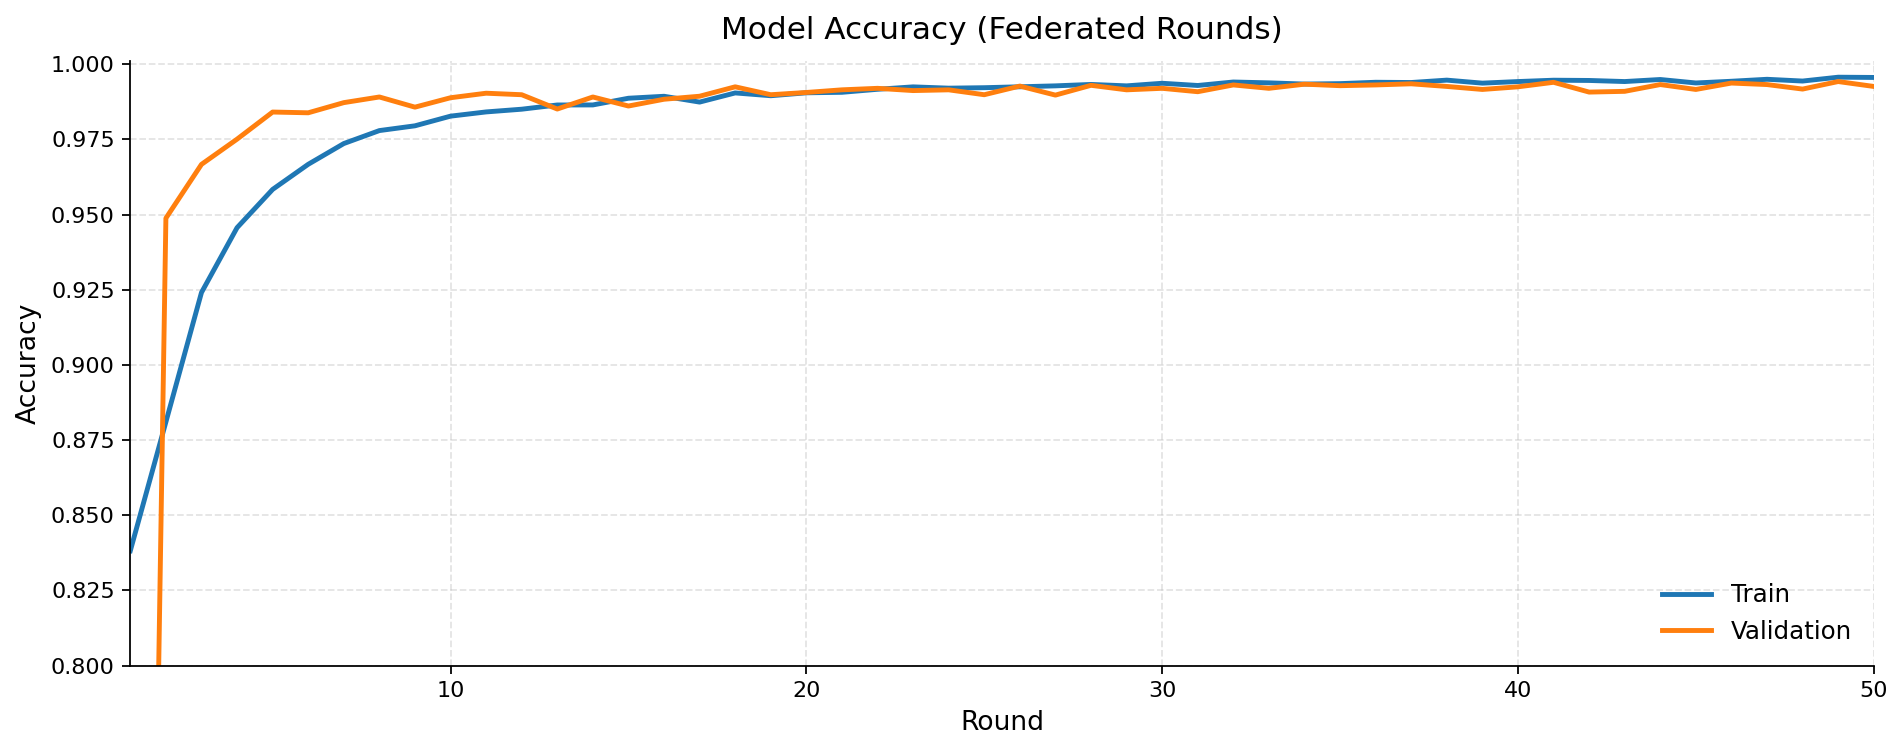

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# If your rounds are stored in fed_hist
train_acc = np.array(fed_hist["train_acc"])
val_acc   = np.array(fed_hist["val_acc"])   # (you labeled it "test" in the legend earlier)

epochs = np.arange(1, len(train_acc) + 1)

plt.figure(figsize=(12, 4.8), dpi=160)

# Lines (no manual colors; matplotlib will pick defaults)
plt.plot(epochs, train_acc, label="Train", linewidth=2.2)
plt.plot(epochs, val_acc,   label="Validation", linewidth=2.2)

# Title + labels
plt.title("Model Accuracy (Federated Rounds)", fontsize=14, pad=10)
plt.xlabel("Round", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

# Clean axis limits (focus where your curves are)
plt.ylim(0.8, 1.001)     # adjust if you want to show the early low values
plt.xlim(1, epochs[-1])

# Nicer ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Subtle grid
plt.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)

# Remove top/right spines (clean look)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
plt.legend(frameon=False, fontsize=11, loc="lower right")

plt.tight_layout()
plt.show()


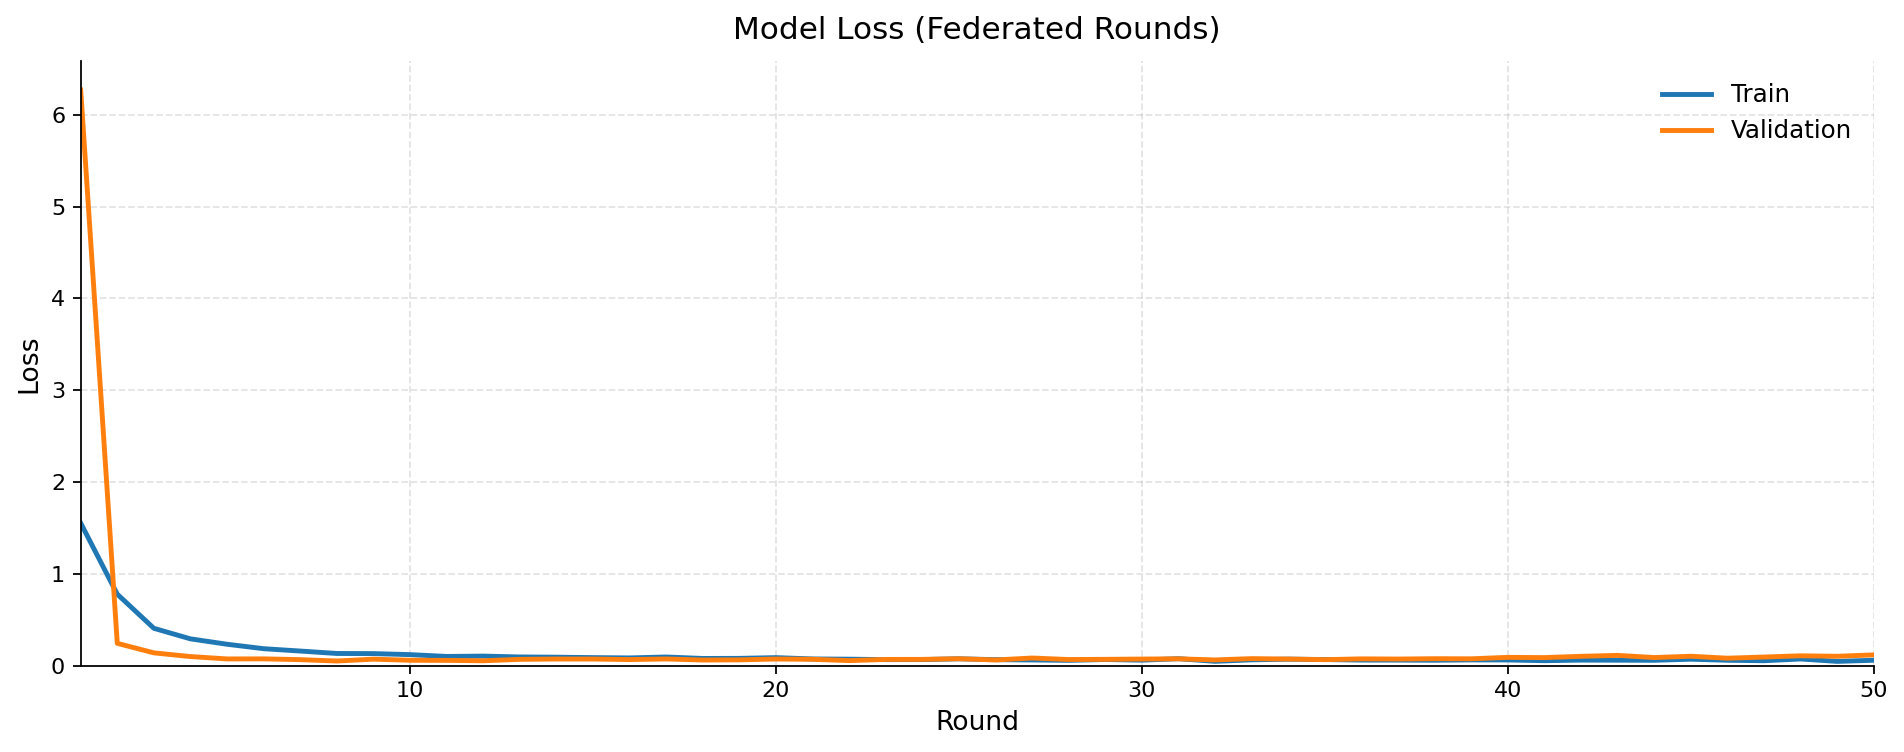

In [29]:
import numpy as np
import matplotlib.pyplot as plt

train_loss = np.array(fed_hist["train_loss"])
val_loss   = np.array(fed_hist["val_loss"])

rounds = np.arange(1, len(train_loss) + 1)

plt.figure(figsize=(12, 4.8), dpi=160)

plt.plot(rounds, train_loss, label="Train", linewidth=2.2)
plt.plot(rounds, val_loss,   label="Validation", linewidth=2.2)

plt.title("Model Loss (Federated Rounds)", fontsize=14, pad=10)
plt.xlabel("Round", fontsize=12)
plt.ylabel("Loss", fontsize=12)

# Focus on meaningful region (adjust if needed)
plt.ylim(0.0, max(train_loss.max(), val_loss.max()) * 1.05)
plt.xlim(1, rounds[-1])

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle="--", linewidth=0.8, alpha=0.35)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [25]:
# Predict probabilities
y_pred_prob = fed_model.predict(test_x)

# Convert to class labels
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(test_y, axis=1)

624/624 [==============================] - 3s 5ms/step


Confusion Matrix:
 [[14873     7    10    43    30]
 [    5  1602     0     0     4]
 [    5     1  1441     0     0]
 [   38     0     2   466     1]
 [   31     5     3     8  1376]]


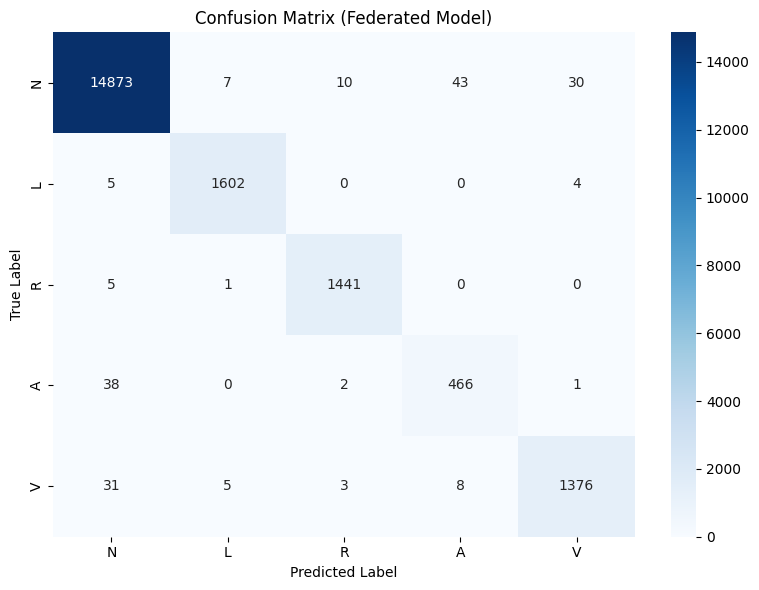

In [26]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Federated Model)")
plt.tight_layout()
plt.show()

In [27]:
report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)

print("Classification Report (Federated Model):\n")
print(report)

Classification Report (Federated Model):

              precision    recall  f1-score   support

           N     0.9947    0.9940    0.9944     14963
           L     0.9920    0.9944    0.9932      1611
           R     0.9897    0.9959    0.9928      1447
           A     0.9014    0.9191    0.9102       507
           V     0.9752    0.9670    0.9711      1423

    accuracy                         0.9903     19951
   macro avg     0.9706    0.9741    0.9723     19951
weighted avg     0.9904    0.9903    0.9903     19951



In [36]:
# ============================================================
# 10) Save / Load (as you had)
# ============================================================
save_dir = r"V:\A\Research\ok\Arrhythmia\models_3"
os.makedirs(save_dir, exist_ok=True)

fed_model_path = os.path.join(save_dir, "fedavg_model.h5")
fed_model.save(fed_model_path)
print("Saved:", fed_model_path)

Saved: V:\A\Research\ok\Arrhythmia\models_3\fedavg_model.h5


In [40]:
fed_model.save("fedavg_savedmodel", save_format="tf")

INFO:tensorflow:Assets written to: fedavg_savedmodel\assets


INFO:tensorflow:Assets written to: fedavg_savedmodel\assets


In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np


In [32]:
# Predict probabilities
y_score = fed_model.predict(test_x)

# True labels (one-hot → class index)
y_true = np.argmax(test_y, axis=1)

# Binarize labels for ROC
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

624/624 [==============================] - 5s 8ms/step


In [33]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [34]:
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(), y_score.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

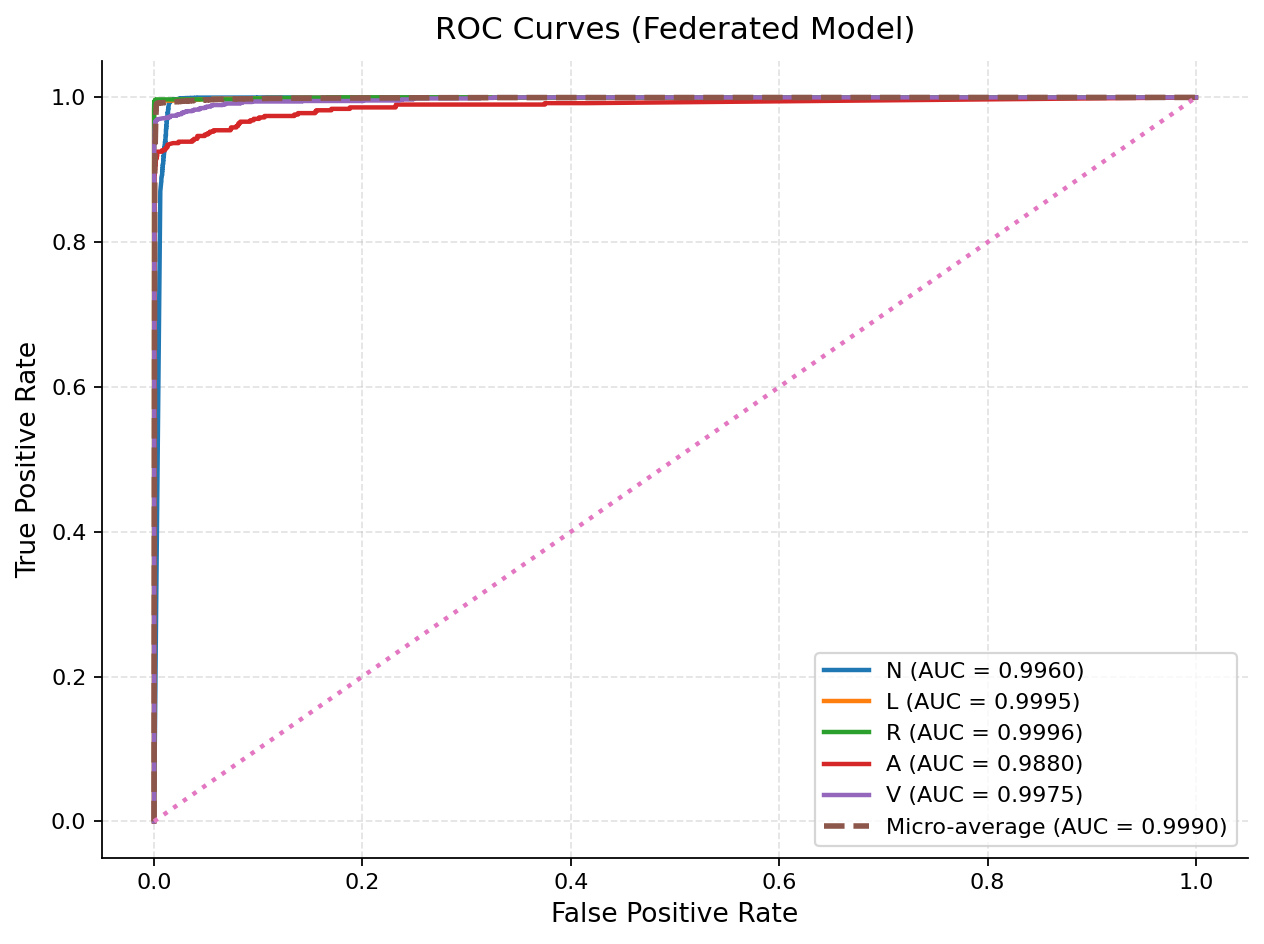

In [35]:
plt.figure(figsize=(8, 6), dpi=160)

# Plot per-class ROC
for i, cls in enumerate(classes):
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{cls} (AUC = {roc_auc[i]:.4f})"
    )

# Plot micro-average ROC
plt.plot(
    fpr["micro"],
    tpr["micro"],
    linestyle="--",
    linewidth=2.5,
    label=f"Micro-average (AUC = {roc_auc['micro']:.4f})"
)

# Diagonal (random classifier)
plt.plot([0, 1], [0, 1], linestyle=":", linewidth=2)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves (Federated Model)", fontsize=14, pad=10)

plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.35)

# Clean spines
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [41]:
import numpy as np
from scipy import stats

# classes used in your project
classes = ["N", "L", "R", "A", "V"]

def predict_custom_signal(model, signal_1d):
    """
    signal_1d: list/np.array of raw ECG values (length must be 2000 if window_size=1000)
    """
    x = np.asarray(signal_1d, dtype=np.float32)

    # 1) length check
    expected_len = model.input_shape[1]  # should be 2000
    if x.shape[0] != expected_len:
        raise ValueError(f"Expected length {expected_len}, got {x.shape[0]}")

    # 2) same preprocessing as training (z-score)
    x = stats.zscore(x)

    # 3) reshape to (1, timesteps, 1)
    x = x.reshape(1, expected_len, 1)

    # 4) predict
    probs = model.predict(x, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    return pred_idx, classes[pred_idx], probs

# Example: custom values (must be length 2000)
custom_signal = np.random.randn(2000)  # replace with your real ECG values

pred_idx, pred_label, probs = predict_custom_signal(fed_model, custom_signal)
print("Pred:", pred_label, "index:", pred_idx)
print("Probabilities:", probs)


Pred: N index: 0
Probabilities: [1. 0. 0. 0. 0.]


In [48]:
import numpy as np

# class mapping: 0=N, 1=L, 2=R, 3=A, 4=V
TARGET_CLASS = 3  # L

# convert one-hot to class index
y_true = np.argmax(test_y, axis=1)

# find first L sample
idx = np.where(y_true == TARGET_CLASS)[0][0]

# extract signal
signal = test_x[idx].squeeze()   # shape -> (2000,)

# print("Index:", idx)
# print("Signal length:", len(signal))
print(signal.tolist())

[0.46797262876079226, 0.6864424896939177, 1.0057445941346397, 1.358657446411227, 1.7115702986878145, 2.1317046466361327, 2.635865864174115, 3.072805586040366, 3.425718438316953, 3.6609936731680115, 3.8122420384294062, 4.030711899362531, 4.249181760295658, 4.484456995146715, 4.7869537256695045, 4.971812838766764, 5.173477325781958, 5.358336438879218, 5.610417047648209, 5.896108404253065, 6.11457826518619, 6.249021256529653, 6.316242752201384, 6.450685743544845, 6.333048126119316, 5.980135273842729, 5.492779430222679, 4.719732229997773, 3.7954366645114734, 2.887946472943106, 2.1148992727182, 1.5099058116726216, 1.0057445941346397, 0.5856102461863214, 0.16547589823800304, -0.03618858877718976, -0.17063158012065163, -0.271463823628248, -0.33868531929997897, -0.43951756280757537, -0.5739605541510372, -0.6915981715765663, -0.7084035454944991, -0.7084035454944991, -0.7420142933303645, -0.7924304150841628, -0.9268734064276246, -0.9604841542634901, -0.9772895281814228, -0.9604841542634901, -0.9

Loaded model: V:\A\Research\ok\Arrhythmia\New folder\fedavg_model.h5
Model input shape: (None, 2000, 1)
Expected length: 2000
Loaded beats: (99754, 2000) labels: (99754,)
Per-class counts: {'N': 74815, 'L': 8053, 'R': 7235, 'A': 2537, 'V': 7114}
Test set: (19951, 2000, 1) (19951,)
Example: 0 Pred: Normal (N) Probs: [1. 0. 0. 0. 0.]
Saved: ecg_ig_overlay.png


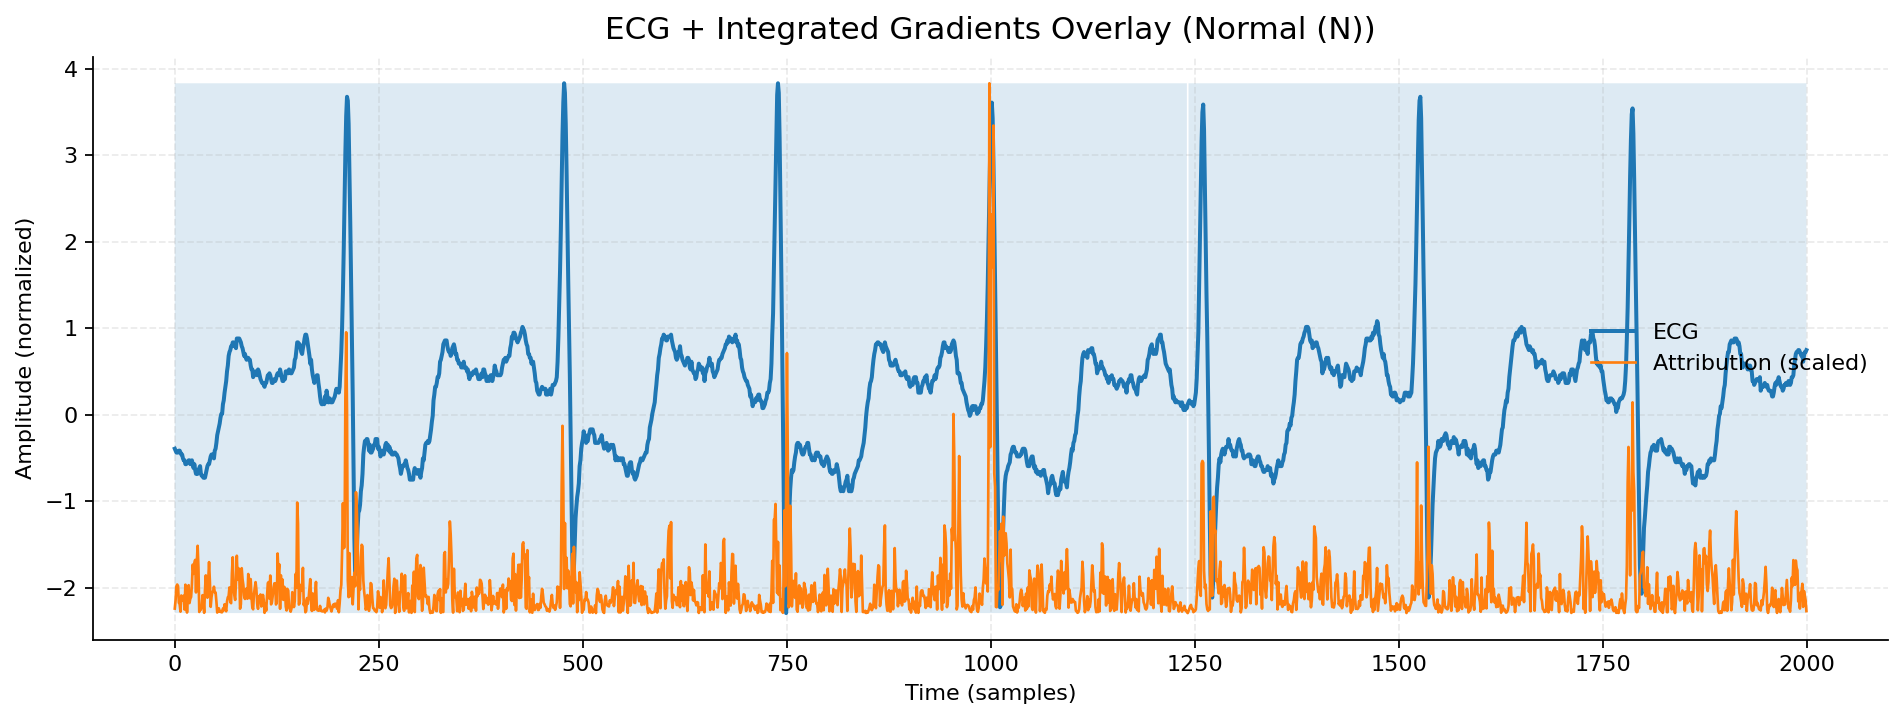

Saved: ig_attribution_only.png


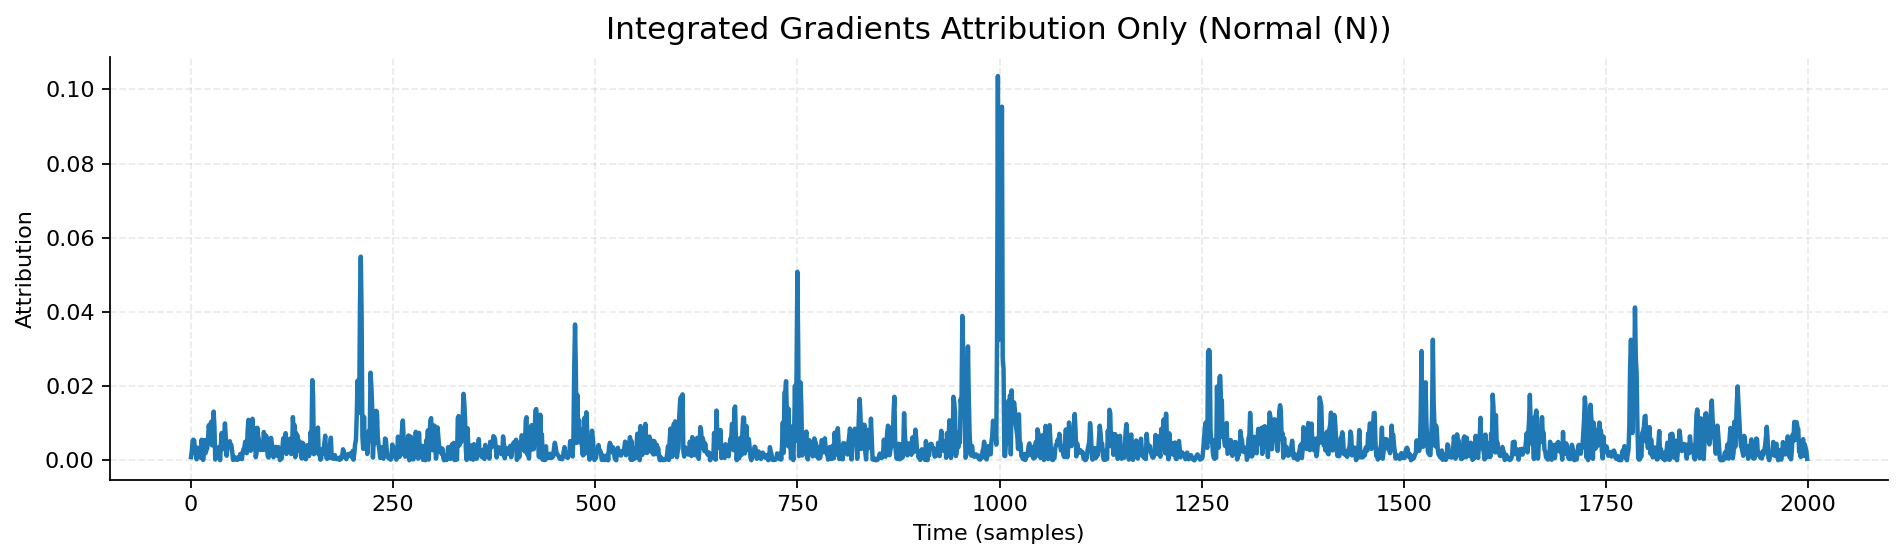

Saved: avg_attr_per_class_ig.png


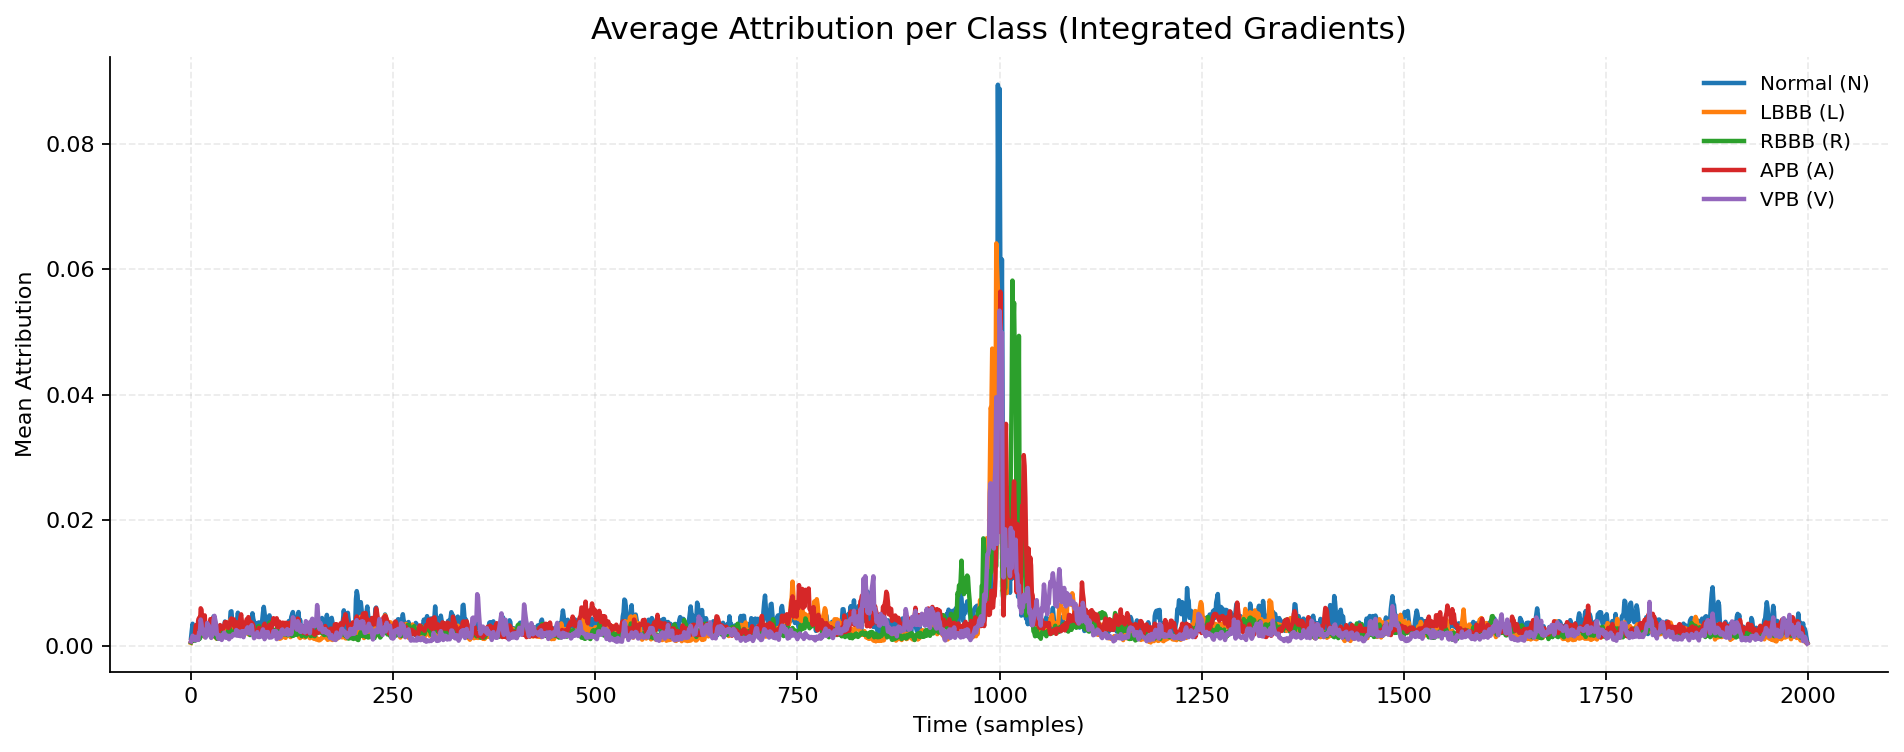

C:\Users\V\AppData\Local\Temp\ipykernel_10368\1925840707.py:291: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


Saved: boxplot_attr_strength_ig.png


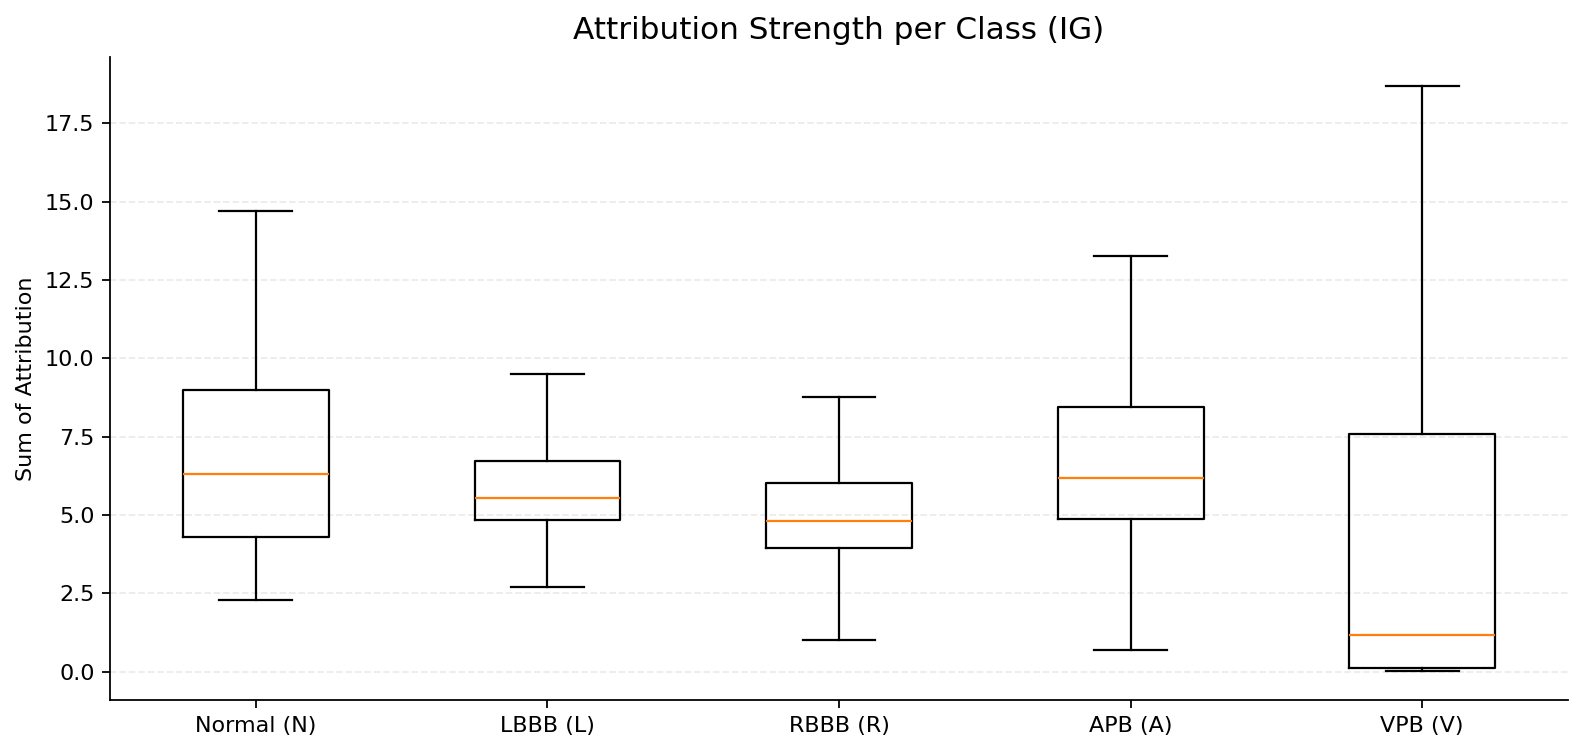

Saved: saliency_vs_ig.png


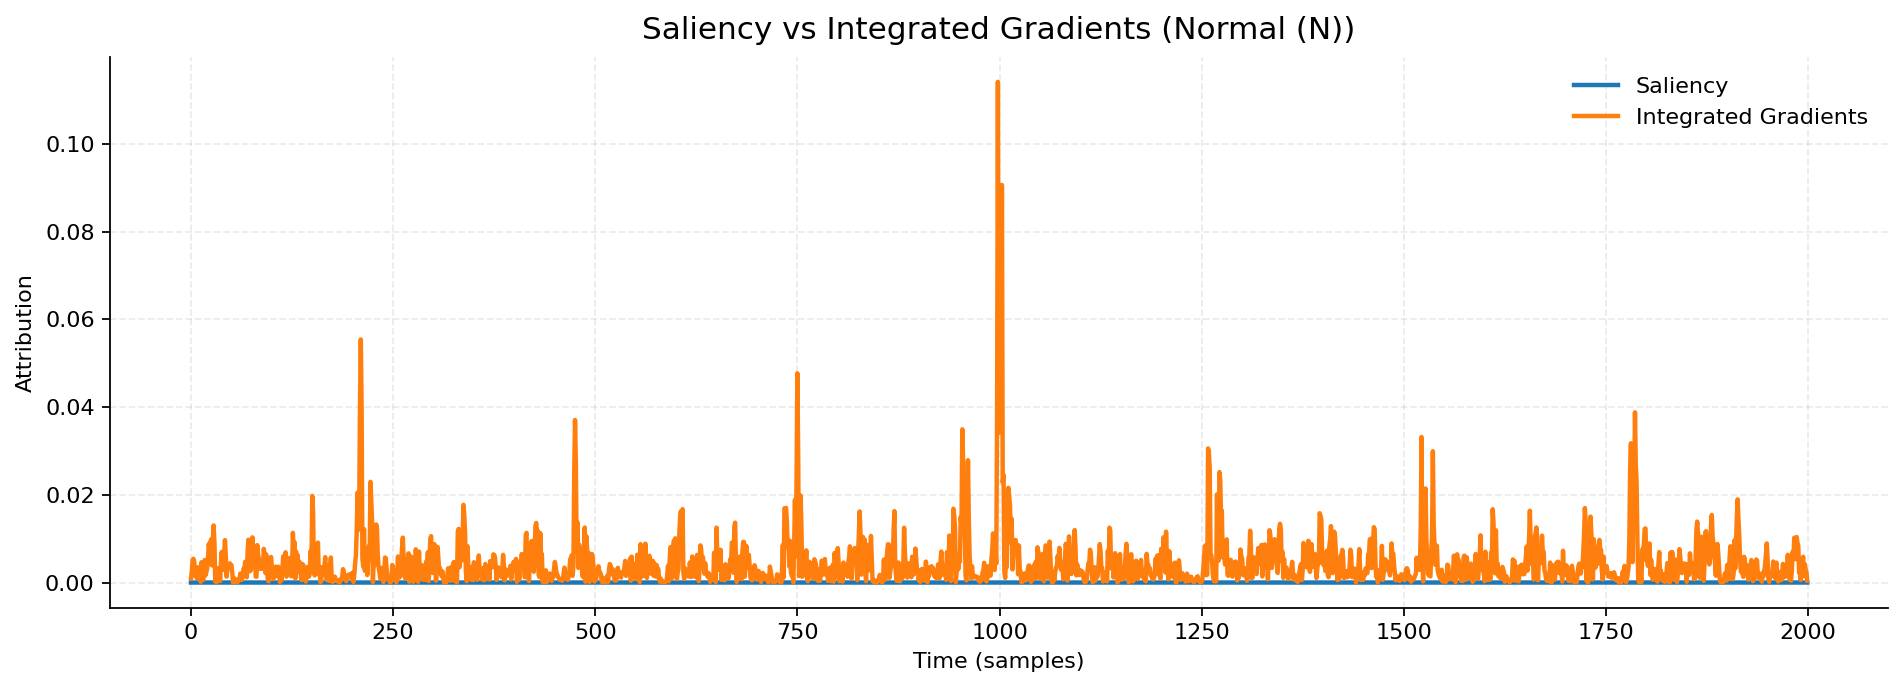

Saved: beeswarm_like_ig.png


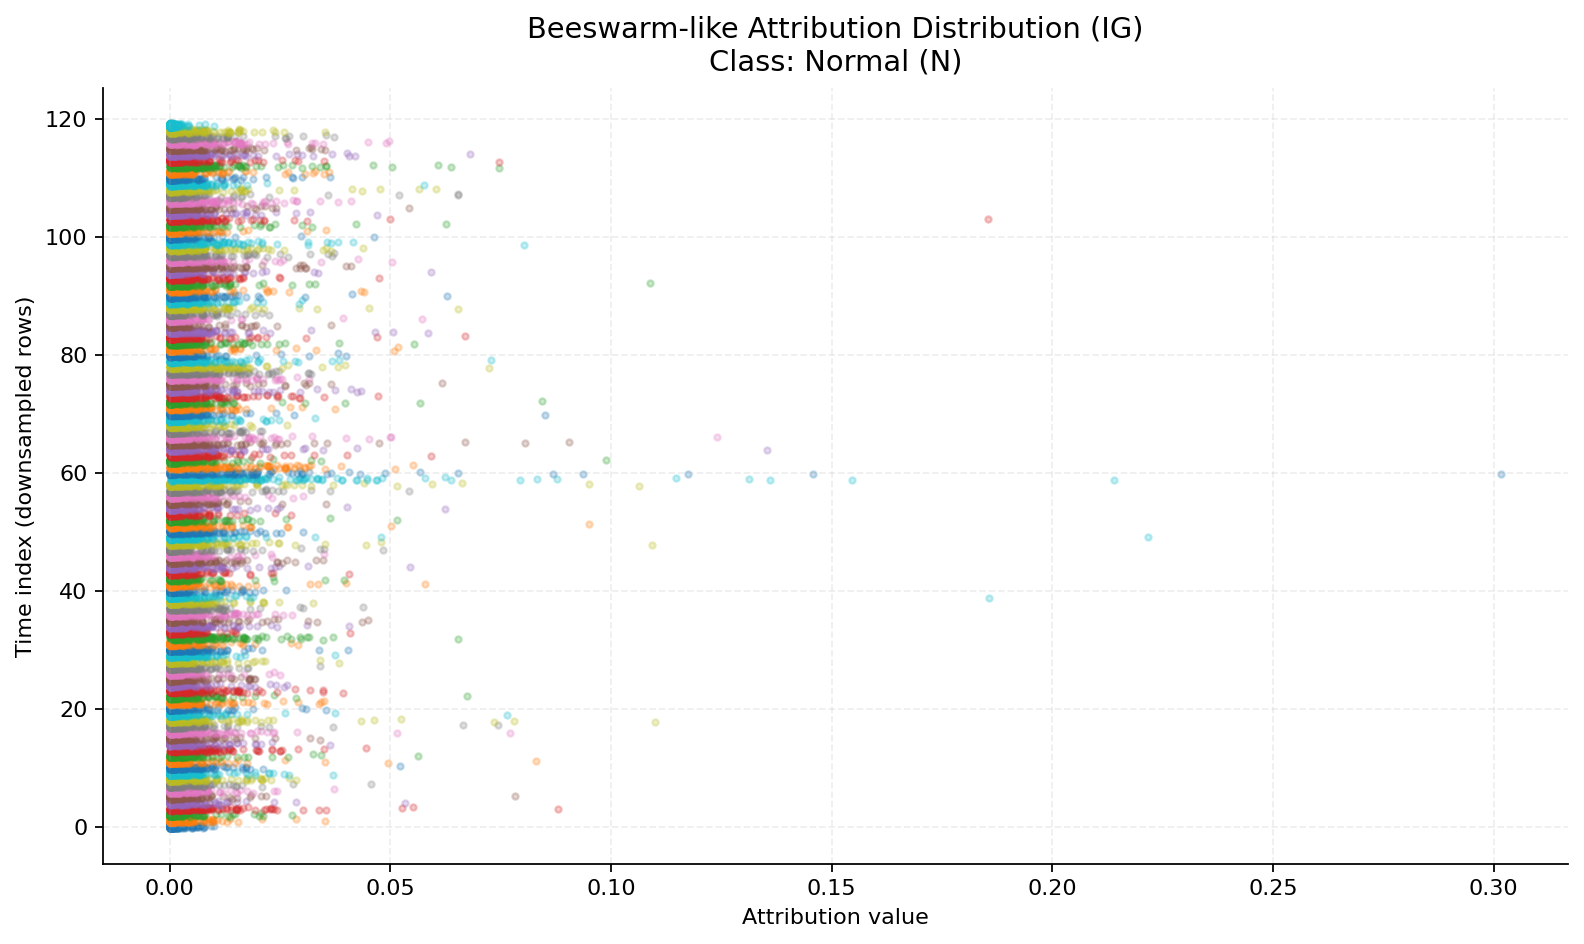

In [1]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split

# ----------------------------
# CONFIG
# ----------------------------
MODEL_PATH = r"V:\A\Research\ok\Arrhythmia\New folder\fedavg_model.h5"
DATASET_FOLDER = r"V:\mitbih_database"   # <-- change if needed
WINDOW_SIZE = 1000                       # same as training; beat length = 2000
TEST_SIZE = 0.20
RANDOM_STATE = 42

CLASSES = ["N", "L", "R", "A", "V"]
CLASS_NAMES = ["Normal (N)", "LBBB (L)", "RBBB (R)", "APB (A)", "VPB (V)"]

# ----------------------------
# 1) Load model
# ----------------------------
model = load_model(MODEL_PATH)
print("Loaded model:", MODEL_PATH)
print("Model input shape:", model.input_shape)

EXPECTED_LEN = model.input_shape[1]
if EXPECTED_LEN is None:
    EXPECTED_LEN = 2 * WINDOW_SIZE  # fallback
print("Expected length:", EXPECTED_LEN)

# ----------------------------
# 2) NumPy-only z-score
# ----------------------------
def zscore_np(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    mu = float(np.mean(x))
    sd = float(np.std(x))
    if sd < 1e-8:
        return x - mu
    return (x - mu) / (sd + 1e-8)

# ----------------------------
# 3) Dataset loader (CSV + annotation, NumPy-only)
#    - reads signals from CSV (column index 1 as you used)
#    - reads annotation from txt (pos in col 2, label in col 3)
#    - extracts beat: [pos-window : pos+window]
# ----------------------------
def load_mitbih_beats(folder: str, window_size: int = 1000, class_symbols=None):
    if class_symbols is None:
        class_symbols = CLASSES

    filenames = next(os.walk(folder))[2]
    filenames.sort()

    records, annotations = [], []
    for f in filenames:
        base, ext = os.path.splitext(f)
        full = os.path.join(folder, f)
        if ext.lower() == ".csv":
            records.append(full)
        elif ext.lower() == ".txt" and "annotation" in base.lower():
            annotations.append(full)

    records.sort()
    annotations.sort()

    if len(records) == 0 or len(annotations) == 0:
        raise FileNotFoundError("No .csv records or annotation*.txt files found in the folder.")

    X, y = [], []
    per_class = {c: 0 for c in class_symbols}

    for r in range(min(len(records), len(annotations))):
        # ---- read signal ----
        sig = []
        with open(records[r], "rt") as csvfile:
            reader = csv.reader(csvfile, delimiter=",", quotechar="|")
            row_index = -1
            for row in reader:
                if row_index >= 0:
                    # same as your notebook: int(row[1])
                    try:
                        sig.insert(row_index, float(row[1]))
                    except:
                        sig.insert(row_index, 0.0)
                row_index += 1

        sig = np.asarray(sig, dtype=np.float32)
        sig = zscore_np(sig)  # same idea as training normalization

        # ---- read annotations ----
        with open(annotations[r], "r") as f:
            lines = f.readlines()

        for d in range(1, len(lines)):  # skip header row
            parts = list(filter(None, lines[d].split(" ")))
            if len(parts) < 3:
                continue

            try:
                pos = int(parts[1])
                arr = parts[2].strip()
            except:
                continue

            if arr in class_symbols and window_size <= pos < (len(sig) - window_size):
                beat = sig[pos - window_size: pos + window_size]
                if beat.shape[0] != 2 * window_size:
                    continue
                X.append(beat)
                y.append(class_symbols.index(arr))
                per_class[arr] += 1

    X = np.asarray(X, dtype=np.float32)  # (N, 2000)
    y = np.asarray(y, dtype=np.int64)

    print("Loaded beats:", X.shape, "labels:", y.shape)
    print("Per-class counts:", per_class)
    return X, y

# ----------------------------
# 4) Build test_x/test_y (NO TRAINING)
# ----------------------------
X, y = load_mitbih_beats(DATASET_FOLDER, window_size=WINDOW_SIZE, class_symbols=CLASSES)

# Ensure correct length (match model input)
if X.shape[1] != EXPECTED_LEN:
    raise ValueError(f"Beat length {X.shape[1]} != model expected length {EXPECTED_LEN}. "
                     f"Check WINDOW_SIZE and training settings.")

_, X_test, _, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

test_x = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
test_y = y_test
print("Test set:", test_x.shape, test_y.shape)

# ----------------------------
# 5) XAI: Saliency + Integrated Gradients
# ----------------------------
def saliency_attribution(ecg_1d: np.ndarray, target_index: int) -> np.ndarray:
    x = ecg_1d.astype(np.float32).reshape(1, -1, 1)
    x_tf = tf.convert_to_tensor(x)

    with tf.GradientTape() as tape:
        tape.watch(x_tf)
        preds = model(x_tf, training=False)
        score = preds[:, target_index]
    grads = tape.gradient(score, x_tf)[0, :, 0]
    return np.abs(grads.numpy())

def integrated_gradients(ecg_1d: np.ndarray, target_index: int, steps: int = 50, baseline="zeros") -> np.ndarray:
    x = ecg_1d.astype(np.float32).reshape(1, -1, 1)
    x_tf = tf.convert_to_tensor(x)

    if baseline == "zeros":
        b_tf = tf.zeros_like(x_tf)
    elif baseline == "mean":
        b_tf = tf.ones_like(x_tf) * tf.reduce_mean(x_tf)
    else:
        raise ValueError("baseline must be 'zeros' or 'mean'")

    alphas = tf.linspace(0.0, 1.0, steps + 1)
    total_grads = tf.zeros_like(x_tf)

    for a in alphas:
        x_interp = b_tf + a * (x_tf - b_tf)
        with tf.GradientTape() as tape:
            tape.watch(x_interp)
            preds = model(x_interp, training=False)
            score = preds[:, target_index]
        grads = tape.gradient(score, x_interp)
        total_grads += grads

    avg_grads = total_grads / tf.cast(tf.size(alphas), tf.float32)
    ig = (x_tf - b_tf) * avg_grads
    return np.abs(ig[0, :, 0].numpy())

# ----------------------------
# 6) Plot helpers (paper style)
# ----------------------------
def savefig(path):
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

def plot_ecg_plus_overlay(ecg, attr, title, outpath):
    T = len(ecg)
    t = np.arange(T)

    # normalize attribution for shading
    a = attr.astype(np.float32)
    if a.max() > 1e-12:
        a = (a - a.min()) / (a.max() - a.min() + 1e-12)
    else:
        a = np.zeros_like(a)

    plt.figure(figsize=(12, 4.6), dpi=160)
    plt.plot(t, ecg, linewidth=1.8, label="ECG")

    # overlay shading using fill_between with alpha varying (simple & clean)
    y0 = np.min(ecg)
    y1 = np.max(ecg)
    plt.fill_between(t, y0, y1, where=a > 0, alpha=0.15)

    # add a thin attribution curve scaled into ECG range (optional but nice)
    attr_scaled = y0 + a * (y1 - y0)
    plt.plot(t, attr_scaled, linewidth=1.2, label="Attribution (scaled)")

    plt.title(title, fontsize=14, pad=8)
    plt.xlabel("Time (samples)")
    plt.ylabel("Amplitude (normalized)")
    plt.grid(True, linestyle="--", alpha=0.25)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.legend(frameon=False)
    plt.tight_layout()
    savefig(outpath)
    plt.show()

def plot_attribution_only(attr, title, outpath):
    plt.figure(figsize=(12, 3.6), dpi=160)
    plt.plot(attr, linewidth=2.0)
    plt.title(title, fontsize=14, pad=8)
    plt.xlabel("Time (samples)")
    plt.ylabel("Attribution")
    plt.grid(True, linestyle="--", alpha=0.25)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    savefig(outpath)
    plt.show()

def plot_average_attribution_per_class(test_x, test_y, method="ig", per_class_n=60, outpath="avg_attr_per_class.png"):
    plt.figure(figsize=(12, 4.8), dpi=160)

    for c in range(len(CLASS_NAMES)):
        idx = np.where(test_y == c)[0]
        if len(idx) == 0:
            continue
        pick = idx[:min(per_class_n, len(idx))]

        attrs = []
        for i in pick:
            ecg = test_x[i, :, 0]
            if method == "ig":
                a = integrated_gradients(ecg, c, steps=50, baseline="zeros")
            else:
                a = saliency_attribution(ecg, c)
            attrs.append(a)

        avg_attr = np.mean(np.stack(attrs, axis=0), axis=0)
        plt.plot(avg_attr, linewidth=2.0, label=CLASS_NAMES[c])

    plt.title(f"Average Attribution per Class ({'Integrated Gradients' if method=='ig' else 'Saliency'})", fontsize=14, pad=8)
    plt.xlabel("Time (samples)")
    plt.ylabel("Mean Attribution")
    plt.legend(frameon=False, fontsize=9, loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.25)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    savefig(outpath)
    plt.show()

def plot_boxplot_attr_strength(test_x, test_y, method="ig", per_class_n=80, outpath="attr_strength_boxplot.png"):
    data, labels = [], []
    for c in range(len(CLASS_NAMES)):
        idx = np.where(test_y == c)[0]
        if len(idx) == 0:
            continue
        pick = idx[:min(per_class_n, len(idx))]

        scores = []
        for i in pick:
            ecg = test_x[i, :, 0]
            if method == "ig":
                a = integrated_gradients(ecg, c, steps=50, baseline="zeros")
            else:
                a = saliency_attribution(ecg, c)
            scores.append(float(np.sum(a)))
        data.append(scores)
        labels.append(CLASS_NAMES[c])

    plt.figure(figsize=(10, 4.8), dpi=160)
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(f"Attribution Strength per Class ({'IG' if method=='ig' else 'Saliency'})", fontsize=14, pad=8)
    plt.ylabel("Sum of Attribution")
    plt.grid(True, axis="y", linestyle="--", alpha=0.25)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    savefig(outpath)
    plt.show()

def plot_saliency_vs_ig(ecg, target_index, outpath="saliency_vs_ig.png"):
    sal = saliency_attribution(ecg, target_index)
    ig = integrated_gradients(ecg, target_index, steps=50, baseline="zeros")

    plt.figure(figsize=(12, 4.4), dpi=160)
    plt.plot(sal, linewidth=2.0, label="Saliency")
    plt.plot(ig, linewidth=2.0, label="Integrated Gradients")
    plt.title(f"Saliency vs Integrated Gradients ({CLASS_NAMES[target_index]})", fontsize=14, pad=8)
    plt.xlabel("Time (samples)")
    plt.ylabel("Attribution")
    plt.legend(frameon=False)
    plt.grid(True, linestyle="--", alpha=0.25)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    savefig(outpath)
    plt.show()

def plot_beeswarm_like(test_x, test_y, target_class=0, method="ig", n_samples=200, outpath="beeswarm_like.png"):
    idx = np.where(test_y == target_class)[0]
    if len(idx) == 0:
        print("No samples for class:", target_class)
        return
    pick = idx[:min(n_samples, len(idx))]

    A = []
    for i in pick:
        ecg = test_x[i, :, 0]
        if method == "ig":
            a = integrated_gradients(ecg, target_class, steps=30, baseline="zeros")
        else:
            a = saliency_attribution(ecg, target_class)
        A.append(a)
    A = np.stack(A, axis=0)  # (N, T)

    # downsample time indices for a beeswarm-like plot
    T = A.shape[1]
    time_idx = np.linspace(0, T - 1, 120).astype(int)

    plt.figure(figsize=(10, 6), dpi=160)
    for j, t in enumerate(time_idx):
        xs = A[:, t]
        ys = np.full_like(xs, j, dtype=np.float32)
        ys = ys + (np.random.rand(xs.shape[0]) - 0.5) * 0.6
        plt.scatter(xs, ys, s=8, alpha=0.25)

    plt.title(f"Beeswarm-like Attribution Distribution ({'IG' if method=='ig' else 'Saliency'})\nClass: {CLASS_NAMES[target_class]}",
              fontsize=13, pad=8)
    plt.xlabel("Attribution value")
    plt.ylabel("Time index (downsampled rows)")
    plt.grid(True, linestyle="--", alpha=0.2)
    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    savefig(outpath)
    plt.show()

# ----------------------------
# 7) Generate plots
# ----------------------------
# pick one example
i = 0
ecg = test_x[i, :, 0]
probs = model.predict(test_x[i:i+1], verbose=0)[0]
pred = int(np.argmax(probs))

print("Example:", i, "Pred:", CLASS_NAMES[pred], "Probs:", probs)

ig_attr = integrated_gradients(ecg, pred, steps=60, baseline="zeros")

plot_ecg_plus_overlay(ecg, ig_attr, f"ECG + Integrated Gradients Overlay ({CLASS_NAMES[pred]})", "ecg_ig_overlay.png")
plot_attribution_only(ig_attr, f"Integrated Gradients Attribution Only ({CLASS_NAMES[pred]})", "ig_attribution_only.png")

plot_average_attribution_per_class(test_x, test_y, method="ig", per_class_n=60, outpath="avg_attr_per_class_ig.png")
plot_boxplot_attr_strength(test_x, test_y, method="ig", per_class_n=80, outpath="boxplot_attr_strength_ig.png")

plot_saliency_vs_ig(ecg, pred, outpath="saliency_vs_ig.png")
plot_beeswarm_like(test_x, test_y, target_class=pred, method="ig", n_samples=200, outpath="beeswarm_like_ig.png")


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def beeswarm_ig(
    X,                  # (N, T, 1)
    y,                  # (N,)
    target_class=0,
    n_samples=300,
    n_bins=50,          # number of segments/features
    steps=30
):
    # pick samples of a class
    idx = np.where(y == target_class)[0]
    if len(idx) == 0:
        raise ValueError("No samples for that class")
    pick = idx[:min(n_samples, len(idx))]

    T = X.shape[1]
    bin_edges = np.linspace(0, T, n_bins+1).astype(int)

    # store (N, n_bins) for impact and (N, n_bins) for feature value
    impacts = np.zeros((len(pick), n_bins), dtype=np.float32)
    featvals = np.zeros((len(pick), n_bins), dtype=np.float32)

    for si, i in enumerate(pick):
        ecg = X[i, :, 0].astype(np.float32)
        # IG attribution for the target class
        attr = integrated_gradients(ecg, target_class, steps=steps, baseline="zeros")

        # aggregate attribution + value per segment
        for b in range(n_bins):
            a0, a1 = bin_edges[b], bin_edges[b+1]
            impacts[si, b] = float(np.mean(attr[a0:a1]))          # impact proxy
            featvals[si, b] = float(np.mean(ecg[a0:a1]))          # segment value for coloring

    # rank bins by mean |impact| (like SHAP summary)
    order = np.argsort(np.mean(np.abs(impacts), axis=0))[::-1]

    impacts = impacts[:, order]
    featvals = featvals[:, order]

    # normalize colors (low->high)
    vmin, vmax = np.percentile(featvals, 5), np.percentile(featvals, 95)

    plt.figure(figsize=(10, 6), dpi=160)

    # beeswarm scatter with jitter
    for j in range(n_bins):
        x = impacts[:, j]
        yj = np.full_like(x, j, dtype=np.float32)
        yj += (np.random.rand(x.shape[0]) - 0.5) * 0.6  # jitter
        plt.scatter(
            x, yj,
            c=np.clip(featvals[:, j], vmin, vmax),
            s=10, alpha=0.5
        )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.yticks(range(n_bins), [f"Segment {k}" for k in order], fontsize=9)
    plt.gca().invert_yaxis()
    plt.xlabel("Attribution impact (IG proxy)")
    plt.ylabel("Time-segment features (ranked)")
    plt.title(
    f"Integrated Gradients Attribution Distribution Across ECG Time Segments ({CLASS_NAMES[target_class]})",
    # fontsize=13, pad=8
)

    cbar = plt.colorbar()
    cbar.set_label("Feature value (segment mean)")
    plt.grid(True, axis="x", linestyle="--", alpha=0.25)
    plt.tight_layout()
    plt.show()

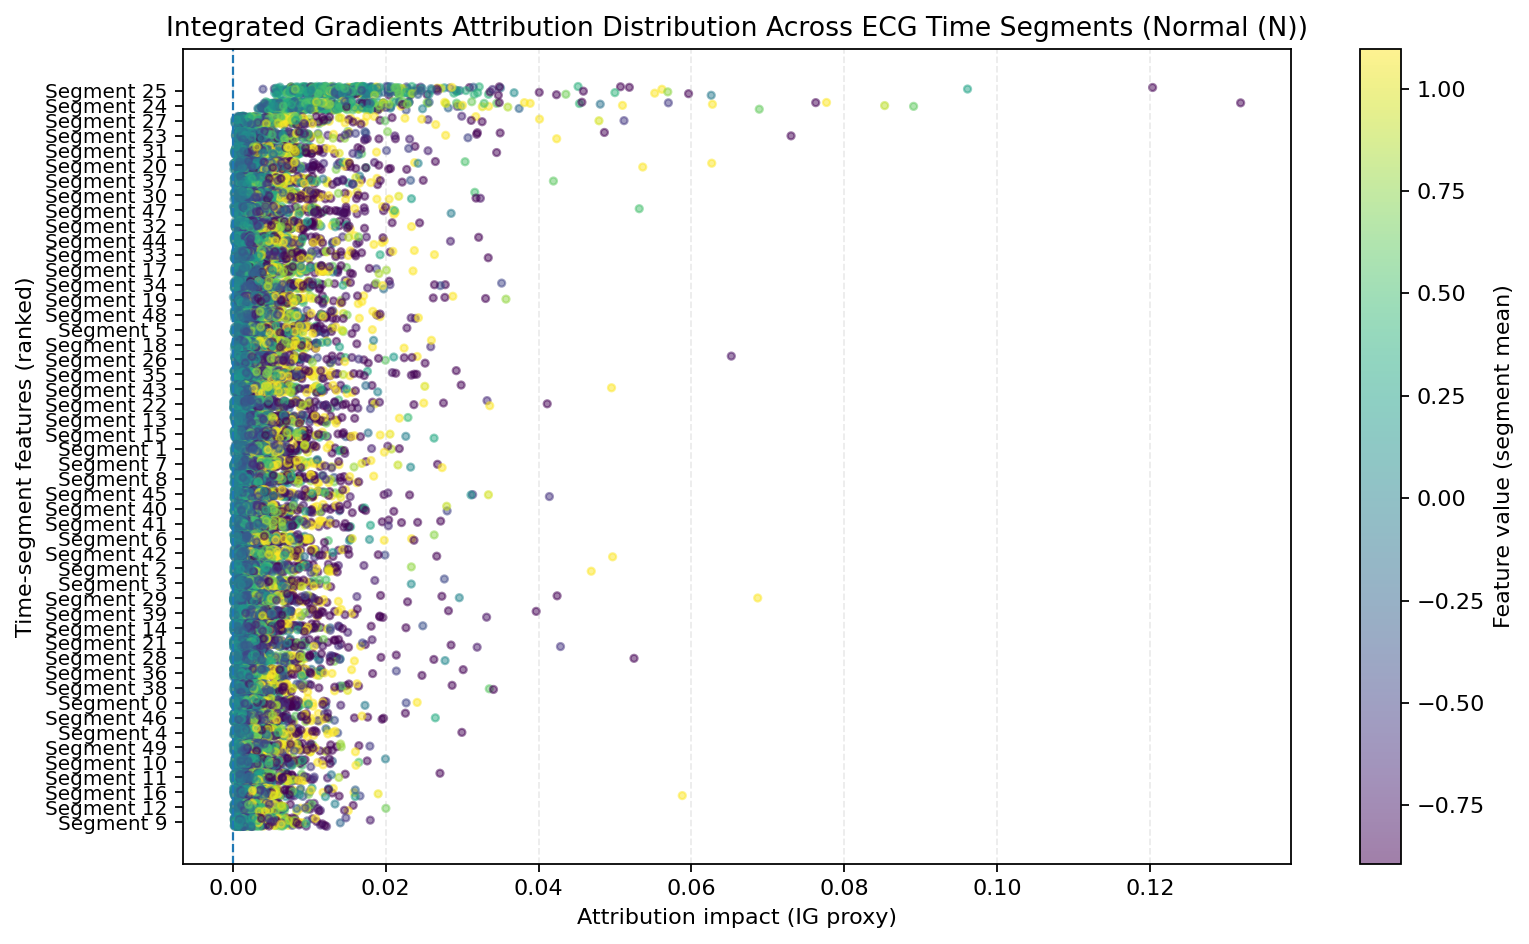

In [5]:
beeswarm_ig(test_x, test_y, target_class=0, n_samples=400, n_bins=50, steps=30)

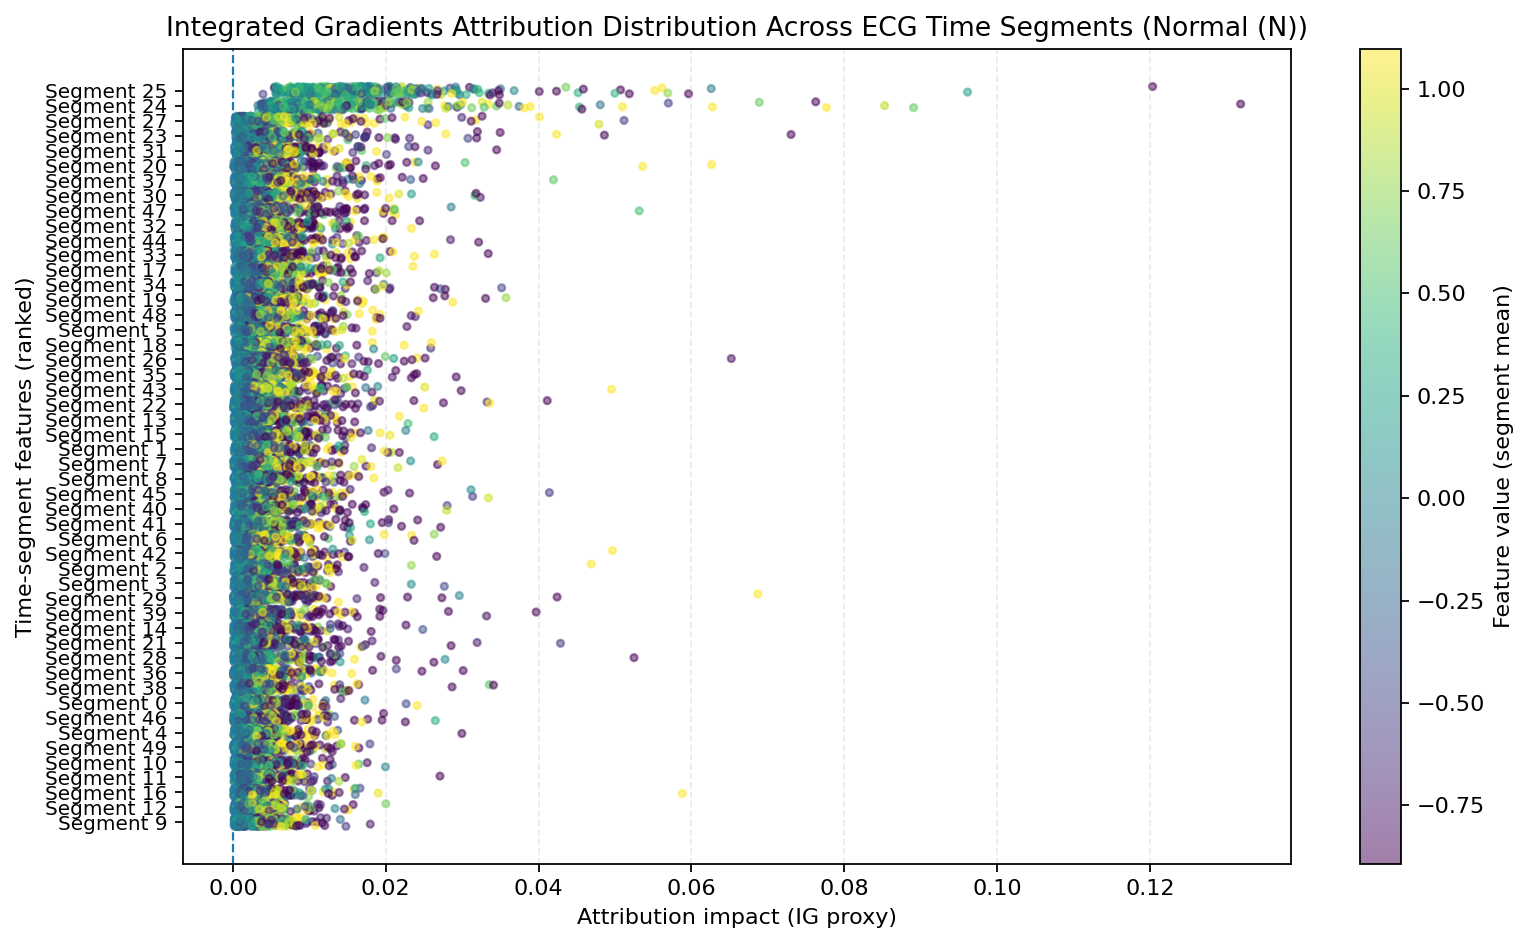

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def beeswarm_ig(
    X,                  # (N, T, 1)
    y,                  # (N,)
    target_class=2,
    n_samples=300,
    n_bins=50,          # number of segments/features
    steps=30
):
    # pick samples of a class
    idx = np.where(y == target_class)[0]
    if len(idx) == 0:
        raise ValueError("No samples for that class")
    pick = idx[:min(n_samples, len(idx))]

    T = X.shape[1]
    bin_edges = np.linspace(0, T, n_bins+1).astype(int)

    # store (N, n_bins) for impact and (N, n_bins) for feature value
    impacts = np.zeros((len(pick), n_bins), dtype=np.float32)
    featvals = np.zeros((len(pick), n_bins), dtype=np.float32)

    for si, i in enumerate(pick):
        ecg = X[i, :, 0].astype(np.float32)
        # IG attribution for the target class
        attr = integrated_gradients(ecg, target_class, steps=steps, baseline="zeros")

        # aggregate attribution + value per segment
        for b in range(n_bins):
            a0, a1 = bin_edges[b], bin_edges[b+1]
            impacts[si, b] = float(np.mean(attr[a0:a1]))          # impact proxy
            featvals[si, b] = float(np.mean(ecg[a0:a1]))          # segment value for coloring

    # rank bins by mean |impact| (like SHAP summary)
    order = np.argsort(np.mean(np.abs(impacts), axis=0))[::-1]

    impacts = impacts[:, order]
    featvals = featvals[:, order]

    # normalize colors (low->high)
    vmin, vmax = np.percentile(featvals, 5), np.percentile(featvals, 95)

    plt.figure(figsize=(10, 6), dpi=160)

    # beeswarm scatter with jitter
    for j in range(n_bins):
        x = impacts[:, j]
        yj = np.full_like(x, j, dtype=np.float32)
        yj += (np.random.rand(x.shape[0]) - 0.5) * 0.6  # jitter
        plt.scatter(
            x, yj,
            c=np.clip(featvals[:, j], vmin, vmax),
            s=10, alpha=0.5
        )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.yticks(range(n_bins), [f"Segment {k}" for k in order], fontsize=9)
    plt.gca().invert_yaxis()
    plt.xlabel("Attribution impact (IG proxy)")
    plt.ylabel("Time-segment features (ranked)")
    plt.title(
    f"Integrated Gradients Attribution Distribution Across ECG Time Segments ({CLASS_NAMES[target_class]})",
    # fontsize=13, pad=8
)

    cbar = plt.colorbar()
    cbar.set_label("Feature value (segment mean)")
    plt.grid(True, axis="x", linestyle="--", alpha=0.25)
    plt.tight_layout()
    plt.show()


beeswarm_ig(test_x, test_y, target_class=0, n_samples=400, n_bins=50, steps=30)